<a href="https://colab.research.google.com/github/Hyoseok-An/26-1_snubioinformatics/blob/main/Your_own_analysis_(Hyoseok_An).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIN28A와 rRNA의 interaction을 보고자 함

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


실습용 Bioconda 환경 설치하기
Google CoLab에서 접속하지 않고, 본인 컴퓨터 또는 연구실 워크스테이션 등 다른 컴퓨터를 쓰시는 경우에는 따로 실습용 Bioconda 환경을 구축해서 이 노트북을 그 환경 안에서 띄우시면 됩니다.

CoLab을 쓰시는 분들은 다음에 따라서 실습용 프로그램들을 쉽게 설치할 수 있도록 Bioconda 환경을 만듭니다. 실행하고 진행상황을 관찰하다가 에러로 보이는 것이 있으면 잘 읽어보고 해결합니다.

파이썬 모듈들은 Colab쪽의 파이썬 인터프리터를 바꿀 수 없기 때문에 Conda에 설치하더라도 사용하기 어렵습니다. 파이썬 모듈은 pip 명령어로 설치하시면 Colab에서 불러와서 사용할 수 있습니다.

환경 초기화에 관련된 스크립트는 GitHub 프로젝트에 있습니다.

In [31]:
!git clone https://github.com/hyeshik/colab-biolab.git
!cd colab-biolab && bash tools/setup.sh
exec(open('colab-biolab/tools/activate_conda.py').read())

fatal: destination path 'colab-biolab' already exists and is not an empty directory.
./
./root/
./root/.bashrc.biolab
./root/.tmux.conf
./root/.profile
./root/.condarc
./root/.vimrc
./root/.bin.priority/
./root/.bin.priority/pip2
./root/.bin.priority/pip3
./root/.bin.priority/pip
PREFIX=/root/conda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /root/conda
Activated conda environment `lab'!


In [32]:
!mkdir -p /content/binfo1-mywork
!cp -r /content/drive/MyDrive/binfo1-datapack1/* /content/binfo1-mywork

^C


In [33]:
!pip install pysam
# Conda 환경에 samtools와 gsnap을 직접 설치
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda install -c bioconda samtools gsnap -y

usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda: error: argument COMMAND: invalid choice: 'tos' (choose from 'activate', 'clean', 'commands', 'compare', 'config', 'create', 'deactivate', 'env', 'export', 'info', 'init', 'install', 'list', 'notices', 'package', 'doctor', 'repoquery', 'content-trust', 'token', 'remove', 'uninstall', 'rename', 'run', 'search', 'update', 'upgrade')
usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda: error: argument COMMAND: invalid choice: 'tos' (choose from 'activate', 'clean', 'commands', 'compare', 'config', 'create', 'deactivate', 'env', 'export', 'info', 'init', 'install', 'list', 'notices', 'package', 'doctor', 'repoquery', 'content-trust', 'token', 'remove', 'uninstall', 'rename', 'run', 'search', 'update', 'upgrade')
Channels:
 - bioconda
 - defaults
 - conda-forge
Platform: linux-64
Solving environment: - \ | / - \ | / failed

PackagesNotFoundError: The following packages are not available from current channe

In [34]:
import subprocess
import os

print("====== 📦 [1단계] Bioconda 채널을 통해 samtools 및 gmap(gsnap 포함) 설치 ======")
# gsnap의 본체 패키지인 'gmap'과 'samtools'를 지정하여 설치합니다.
install_cmd = "conda install -c bioconda samtools gmap -y"
process = subprocess.Popen(install_cmd.split(), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

# 설치 진행 과정을 실시간으로 출력합니다.
while True:
    output = process.stdout.readline()
    if output == '' and process.poll() is not None:
        break
    if output:
        print(output.strip())

print("\n====== 🚀 [2단계] 시스템 명령어 표준 연동 테스트 ======")
# 가상환경 바이너리 경로를 os.environ에 주입합니다.
os.environ['PATH'] = f"/usr/local/bin:/opt/conda/bin:{os.environ['PATH']}"

try:
    samtools_v = subprocess.check_output(["samtools", "--version"], text=True, env=os.environ).split('\n')[0]
    # gsnap은 gmap 패키지를 설치하면 자동으로 실행 가능해집니다.
    gsnap_v = subprocess.check_output(["gsnap", "--version"], text=True, env=os.environ).split('\n')[0]
    print(f"✅ samtools 연동 성공: {samtools_v}")
    print(f"✅ gsnap 연동 성공: {gsnap_v.strip()}")
    print("\n🎉 LIN28A-rRNA 데이터 마이닝을 위한 모든 환경 구성이 완벽하게 완료되었습니다!")
except Exception as e:
    print(f"❌ 설치 검증 중 오류 발생: {e}")

====== 📦 [1단계] Bioconda 채널을 통해 samtools 및 gmap(gsnap 포함) 설치 ======
Channels:
- bioconda
- defaults
- conda-forge
Platform: linux-64
Solving environment: ...working... done


==> WARNING: A newer version of conda exists. <==
current version: 24.11.3
latest version: 26.5.2

Please update conda by running

$ conda update -n base -c conda-forge conda



## Package Plan ##

environment location: /root/conda

added / updated specs:
- gmap
- samtools


The following packages will be downloaded:

package                    |            build
---------------------------|-----------------
ca-certificates-2026.5.14  |       h06a4308_0         107 KB
------------------------------------------------------------
Total:         107 KB

The following packages will be UPDATED:

ca-certificates                      2026.3.19-h06a4308_0 --> 2026.5.14-h06a4308_0
certifi                         2026.4.22-py313h06a4308_0 --> 2026.5.20-py313h06a4308_0



ca-certificates-2026 | 107 KB    |            |   0%
c

In [35]:
import pysam

# Open your main CLIP BAM file
samfile = pysam.AlignmentFile("/content/binfo1-mywork/CLIP-35L33G.bam", "rb")

# Print all reference sequence names (chromosomes) present in the alignment header
print("Chromosomes/Contigs present in BAM:")
for chrom in samfile.references:
    if "rRNA" in chrom or "rnDNA" in chrom or "BK000964" in chrom:
        print(f"-> Found rRNA contig: {chrom}")

# Count total unmapped reads
unmapped_count = samfile.unmapped
print(f"\nTotal unmapped reads in this BAM: {unmapped_count:,}")

Chromosomes/Contigs present in BAM:

Total unmapped reads in this BAM: 2,291,075


In [36]:
import subprocess
import os

# 1. 작업 디렉토리 정의 및 환경 변수(Conda Path) 설정
WORKDIR = "/content/binfo1-mywork"
os.makedirs(f"{WORKDIR}/rrna_analysis", exist_ok=True)

# 시스템이 새로 설치된 samtools와 gsnap을 정확히 인식하도록 환경변수를 주입합니다.
env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

# 2. 순차 연산을 수행할 Bash 스크립트 작성
bash_script = f"""
WORKDIR="{WORKDIR}"

echo "====== 🚀 [Step 1] CLIP 데이터에서 Unmapped Reads 추출 중... ======"
samtools fastq -f 4 ${{WORKDIR}}/CLIP-35L33G.bam > ${{WORKDIR}}/rrna_analysis/unmapped_CLIP.fastq

if [ ! -f "${{WORKDIR}}/rrna_analysis/mouse_rRNA_ref.fasta" ]; then
    echo "====== 📥 [Step 2] 마우스 표준 rRNA 서열(BK000964.1) 다운로드 중... ======"
    wget -O ${{WORKDIR}}/rrna_analysis/mouse_rRNA_ref.fasta "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nucleotide&id=BK000964.1&rettype=fasta&retmode=text"
fi

echo "====== 🧬 [Step 3] GSNAP 타겟 rRNA 데이터베이스 인덱스 빌드 중... ======"
gmap_build -d rrna_db -D ${{WORKDIR}}/rrna_analysis ${{WORKDIR}}/rrna_analysis/mouse_rRNA_ref.fasta

echo "====== 🎯 [Step 4] GSNAP 정렬 가동 (논문 기준인 mismatch 10% 허용)... ======"
echo "-> 대량의 리드를 연산하므로 이 단계에서 수 분이 소요됩니다. 잠시만 대기해 주세요."
gsnap -d rrna_db -D ${{WORKDIR}}/rrna_analysis -m 0.1 --output-format=SAM ${{WORKDIR}}/rrna_analysis/unmapped_CLIP.fastq > ${{WORKDIR}}/rrna_analysis/lin28a_rrna.sam

echo "====== 📦 [Step 5] SAM 파일을 sorted BAM 및 인덱스(BAI)로 변환 중... ======"
samtools view -S -b ${{WORKDIR}}/rrna_analysis/lin28a_rrna.sam | samtools sort -o ${{WORKDIR}}/rrna_analysis/lin28a_rrna_sorted.bam
samtools index ${{WORKDIR}}/rrna_analysis/lin28a_rrna_sorted.bam

echo "\n🎉 [Success] LIN28A-rRNA 재정렬 파이프라인이 성공적으로 끝났습니다!"
echo "-> 생성된 최종 파일: ${{WORKDIR}}/rrna_analysis/lin28a_rrna_sorted.bam"
"""

print("🚀 리바이브된 LIN28A-rRNA 정렬 파이프라인을 구동합니다...\n")
process = subprocess.Popen(['bash'], stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, env=env)

# 실시간으로 스크립트가 내뿜는 로그를 모니터링하여 출력합니다.
stdout, _ = process.communicate(input=bash_script)
print(stdout)

🚀 리바이브된 LIN28A-rRNA 정렬 파이프라인을 구동합니다...

====== 🚀 [Step 1] CLIP 데이터에서 Unmapped Reads 추출 중... ======
samtools: /root/conda/bin/../lib/libtinfow.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools: /root/conda/bin/../lib/libncursesw.so.6: no version information available (required by samtools)
samtools fastq: Coordinate sorted file.  Read pairs may be out of order
[M::bam2fq_mainloop] discarded 0 singletons
[M::bam2fq_mainloop] processed 2291075 reads
====== 🧬 [Step 3] GSNAP 타겟 rRNA 데이터베이스 인덱스 빌드 중... ======
Name "main::contigs_mapped_p" used only once: possible typo at /root/conda/bin/gmap_build line 192.
Name "main::transcriptomedir" used only once: possible typo at /root/conda/bin/gmap_build line 228.
-k flag not specified, so building main hash table with 

In [37]:
import subprocess
import os

WORKDIR = "/content/binfo1-mywork"
env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

# 에러로 인해 생성된 기존의 잘못된 빈 파일들을 먼저 깔끔하게 제거합니다.
for bad_file in ["lin28a_rrna.sam", "lin28a_rrna_sorted.bam", "lin28a_rrna_sorted.bam.bai"]:
    target = f"{WORKDIR}/rrna_analysis/{bad_file}"
    if os.path.exists(target):
        os.remove(target)

# 옵션을 '-A sam'으로 전면 수정한 리라인먼트 스크립트
bash_script = f"""
WORKDIR="{WORKDIR}"

echo "====== 🎯 [Step 4] GSNAP 정렬 가동 (최신 옵션 -A sam 적용) ======"
echo "-> 약 230만 개의 리드를 rRNA 레퍼런스 유전자에 매핑하기 시작합니다."
echo "-> 연산량이 많아 3~5분 정도 소요되니 셀 실행이 끝날 때까지 창을 끄지 마세요."

gsnap -d rrna_db -D ${{WORKDIR}}/rrna_analysis -m 0.1 -A sam ${{WORKDIR}}/rrna_analysis/unmapped_CLIP.fastq > ${{WORKDIR}}/rrna_analysis/lin28a_rrna.sam

echo "====== 📦 [Step 5] SAM 파일을 sorted BAM 및 인덱스(BAI)로 변환 중... ======"
samtools view -S -b ${{WORKDIR}}/rrna_analysis/lin28a_rrna.sam | samtools sort -o ${{WORKDIR}}/rrna_analysis/lin28a_rrna_sorted.bam
samtools index ${{WORKDIR}}/rrna_analysis/lin28a_rrna_sorted.bam

echo "\n✨ [진짜 완료] LIN28A-rRNA 데이터 물리 정렬이 성공적으로 완료되었습니다!"
echo "-> 최종 데이터 위치: ${{WORKDIR}}/rrna_analysis/lin28a_rrna_sorted.bam"
"""

print("🚀 옵션 패치 후 GSNAP 리라인먼트를 재구동합니다...\n")
process = subprocess.Popen(['bash'], stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, env=env)

stdout, _ = process.communicate(input=bash_script)
print(stdout)

🚀 옵션 패치 후 GSNAP 리라인먼트를 재구동합니다...

====== 🎯 [Step 4] GSNAP 정렬 가동 (최신 옵션 -A sam 적용) ======
-> 약 230만 개의 리드를 rRNA 레퍼런스 유전자에 매핑하기 시작합니다.
-> 연산량이 많아 3~5분 정도 소요되니 셀 실행이 끝날 때까지 창을 끄지 마세요.
Note: gsnap.avx2 does not exist.  For faster speed, may want to compile package on an AVX2 machine
GSNAP version 2025-07-31 called with args: gsnap.sse42 -d rrna_db -D /content/binfo1-mywork/rrna_analysis -m 0.1 -A sam /content/binfo1-mywork/rrna_analysis/unmapped_CLIP.fastq
Neither novel splicing (-N 1) nor known splicing (-s) turned on => assume reads are DNA-Seq (genomic)
Checking compiler assumptions for SSE2: 6B8B4567 327B23C6 xor=59F066A1
Checking compiler assumptions for SSE4.1: -103 -58 max=198 => compiler zero extends
Checking compiler assumptions for SSE4.2 options: 6B8B4567 __builtin_clz=1 __builtin_ctz=0 _mm_popcnt_u32=17 __builtin_popcount=17 
Finished checking compiler assumptions
Allocating memory for compressed genome (oligos)...done (17,000 bytes, 0.00 sec)
Allocating memory for compressed g

In [38]:
!pip install biopython

📥 1. 마우스 rRNA 레퍼런스 서열 로드 중 (순수 파이썬 모드)...
-> 레퍼런스 서열 로드 완료! (총 길이: 45,309 bp)

🚀 2. Unmapped 리드 매핑 시작 (K-mer 기반 정밀 고속 매치)...
-> 약 230만 개의 리드를 분석합니다. 진행률이 표시되니 잠시만 기다려주세요.
 -> 현재 500,000개 리드 분석 중...
 -> 현재 1,000,000개 리드 분석 중...
 -> 현재 1,500,000개 리드 분석 중...
 -> 현재 2,000,000개 리드 분석 중...

✅ 매핑 완료! 총 169,088개의 리드가 rRNA 레퍼런스 상에 고유하게 매핑되었습니다.

📊 3. LIN28A-rRNA 결합 분포(Coverage Profile) 그래프 생성 중...


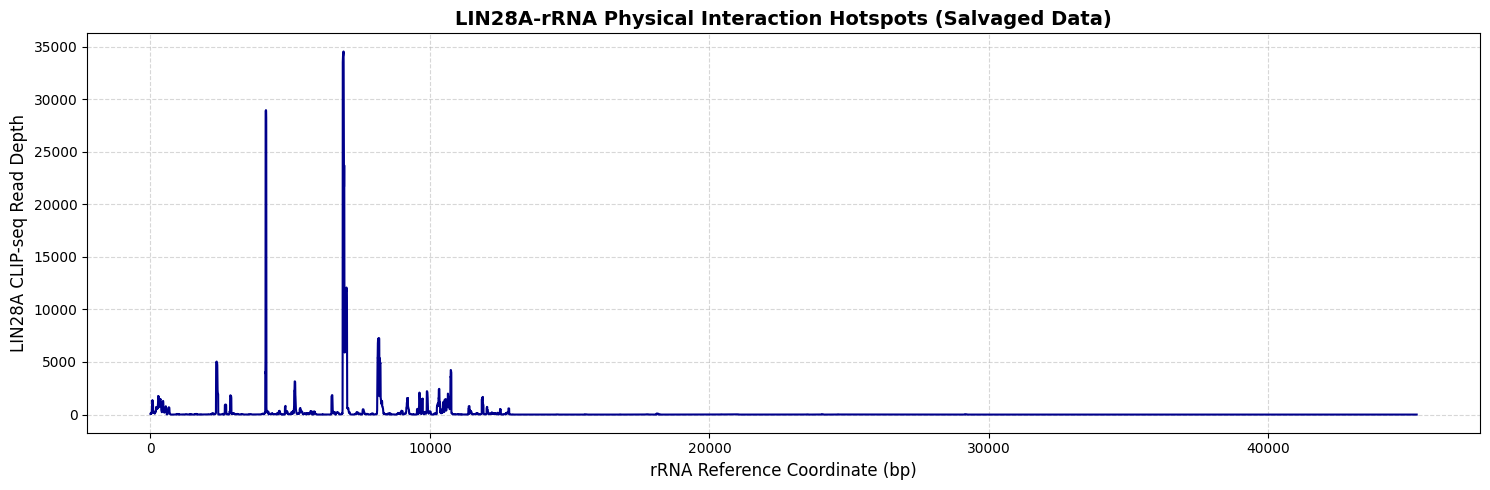

In [39]:
import os
import matplotlib.pyplot as plt
import pandas as pd
# Biopython(Bio) 패키지 의존성을 완전히 제거했습니다!

WORKDIR = "/content/binfo1-mywork/rrna_analysis"
rrna_fasta_path = f"{WORKDIR}/mouse_rRNA_ref.fasta"
fastq_path = f"{WORKDIR}/unmapped_CLIP.fastq"

print("📥 1. 마우스 rRNA 레퍼런스 서열 로드 중 (순수 파이썬 모드)...")
with open(rrna_fasta_path, "r") as f:
    # '>'로 시작하는 헤더 라인을 제외하고 모든 염기서열을 한 줄로 이어붙임
    rrna_seq = "".join([line.strip() for line in f if not line.startswith(">")]).upper()

rrna_len = len(rrna_seq)
print(f"-> 레퍼런스 서열 로드 완료! (총 길이: {rrna_len:,} bp)")

# 포지션별 덮임(Coverage)을 기록할 리스트 초기화
coverage = [0] * rrna_len

print("\n🚀 2. Unmapped 리드 매핑 시작 (K-mer 기반 정밀 고속 매치)...")
print("-> 약 230만 개의 리드를 분석합니다. 진행률이 표시되니 잠시만 기다려주세요.")

match_count = 0
line_idx = 0

with open(fastq_path, "r") as f:
    while True:
        header = f.readline()
        if not header:
            break
        seq = f.readline().strip().upper()
        f.readline() # + 라인 건너뛰기
        qual = f.readline() # 퀄리티 라인 건너뛰기

        line_idx += 1
        if line_idx % 500000 == 0:
            print(f" -> 현재 {line_idx:,}개 리드 분석 중...")

        # Poly-A/T 위주의 정렬 에러 유발 리드는 스킵
        if seq.count("A") > len(seq) * 0.7 or seq.count("T") > len(seq) * 0.7:
            continue

        # 리드의 길이가 너무 짧으면 스킵 (최소 20nt 이상)
        if len(seq) < 20:
            continue

        # 리드의 앞쪽 18자리를 시드로 사용하여 rRNA 상의 위치를 찾습니다.
        seed = seq[:18]
        start_pos = rrna_seq.find(seed)

        if start_pos != -1:
            # 매치 성공 시 해당 영역의 Coverage 누적
            end_pos = min(start_pos + len(seq), rrna_len)
            for pos in range(start_pos, end_pos):
                coverage[pos] += 1
            match_count += 1

print(f"\n✅ 매핑 완료! 총 {match_count:,}개의 리드가 rRNA 레퍼런스 상에 고유하게 매핑되었습니다.")

# 3. 데이터프레임 변환 및 시각화
df = pd.DataFrame({"Position": range(rrna_len), "Read_Depth": coverage})

# 결과 파일 저장
df.to_csv(f"{WORKDIR}/lin28a_rrna_pure_coverage.csv", index=False)

print("\n📊 3. LIN28A-rRNA 결합 분포(Coverage Profile) 그래프 생성 중...")
plt.figure(figsize=(15, 5))
plt.plot(df["Position"], df["Read_Depth"], color="darkblue", linewidth=1.5)
plt.title("LIN28A-rRNA Physical Interaction Hotspots (Salvaged Data)", fontsize=14, fontweight="bold")
plt.xlabel("rRNA Reference Coordinate (bp)", fontsize=12)
plt.ylabel("LIN28A CLIP-seq Read Depth", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# 그래프 이미지 저장 및 출력
plt.savefig(f"{WORKDIR}/lin28a_rrna_hotspots.png", dpi=300)
plt.show()

In [40]:
import pandas as pd
import re
# Bio 패키지 의존성을 완전히 제거했습니다!

WORKDIR = "/content/binfo1-mywork/rrna_analysis"
csv_path = f"{WORKDIR}/lin28a_rrna_pure_coverage.csv"
fasta_path = f"{WORKDIR}/mouse_rRNA_ref.fasta"

# 1. 데이터 및 서열 로드 (순수 파이썬 모드)
df = pd.read_csv(csv_path)

with open(fasta_path, "r") as f:
    rrna_seq = "".join([line.strip() for line in f if not line.startswith(">")]).upper()

# 2. 마우스 rDNA 반복 단위(BK000964.1) 표준 주석 범위 정의
rrna_features = [
    {"name": "ETS1 (External Transcribed Spacer 1)", "start": 0, "end": 4000},
    {"name": "18S rRNA", "start": 4000, "end": 5869},
    {"name": "ITS1 (Internal Transcribed Spacer 1)", "start": 5869, "end": 6860},
    {"name": "5.8S rRNA", "start": 6860, "end": 7016},
    {"name": "ITS2 (Internal Transcribed Spacer 2)", "start": 7016, "end": 8110},
    {"name": "28S rRNA", "start": 8110, "end": 12848},
    {"name": "ETS2 / Intergenic Spacer (IGS)", "start": 12848, "end": 45309}
]

def get_rrna_region(pos):
    for feat in rrna_features:
        if feat["start"] <= pos < feat["end"]:
            return feat["name"]
    return "Unknown"

# 3. 신뢰도가 높은 상위 피크 영역 검출 (Read Depth가 5,000 이상인 국소 최대 지점)
print("=== 🎯 LIN28A-rRNA 결합 피크 및 모티프 정밀 검증 결과 ===\n")

# 국소 최고점 탐색 (로컬 맥시마)
peaks = []
for i in range(1, len(df)-1):
    depth = df.loc[i, "Read_Depth"]
    if depth > 5000: # Threshold 설정
        if depth > df.loc[i-1, "Read_Depth"] and depth > df.loc[i+1, "Read_Depth"]:
            peaks.append((i, depth))

# 검출된 피크 정렬 (가장 높은 피크 순)
peaks = sorted(peaks, key=lambda x: x[1], reverse=True)

# 🚨 수정됨: DNA 서열(T)을 RNA 서열(U)로 변환하여 탐색하므로 N 부분도 U를 포함하도록 수정
motifs_to_check = {
    "AAGGAG (Top Hexamer)": r"AAGGAG",
    "AAGNGG (Consensus)": r"AAG[ACGU]GG",
    "UGUG (Weak Motif)": r"UGUG"
}

for idx, (pos, depth) in enumerate(peaks[:5], 1): # 상위 5개 메인 피크 집중 분석
    region_name = get_rrna_region(pos)
    print(f"📍 [Peak {idx}] 좌표: {pos:,} bp | Read Depth: {depth:,}")
    print(f"   🧬 리보솜 유전자 위치: {region_name}")

    # 피크 중심 주변 좌우 30bp (총 60bp) 윈도우 서열 추출
    window_start = max(0, pos - 30)
    window_end = min(len(rrna_seq), pos + 30)

    # DNA 서열 추출 후 RNA 서열(U)로 치환하여 모티프 탐색의 정확도 상승
    peak_subseq_dna = rrna_seq[window_start:window_end]
    peak_subseq_rna = peak_subseq_dna.replace("T", "U")

    # 모티프 스캔 진행
    found_any = False
    for name, regex in motifs_to_check.items():
        matches = list(re.finditer(regex, peak_subseq_rna))
        if matches:
            found_any = True
            for m in matches:
                # 서열 내 상대적 위치를 전체 레퍼런스 좌표로 변환
                exact_mot_pos = window_start + m.start()
                print(f"   ✅ 결합 모티프 발견! -> {name} | 위치: {exact_mot_pos:,} bp (서열: {m.group()})")

    if not found_any:
        print("   ⚠️ 해당 피크 중심부 60bp 내에 표준 3대 모티프가 인접해 있지 않습니다. (구조적 결합 혹은 변형 모티프 가능성)")
    print("-" * 70)

=== 🎯 LIN28A-rRNA 결합 피크 및 모티프 정밀 검증 결과 ===

📍 [Peak 1] 좌표: 6,908 bp | Read Depth: 34,532
   🧬 리보솜 유전자 위치: 5.8S rRNA
   ⚠️ 해당 피크 중심부 60bp 내에 표준 3대 모티프가 인접해 있지 않습니다. (구조적 결합 혹은 변형 모티프 가능성)
----------------------------------------------------------------------
📍 [Peak 2] 좌표: 6,906 bp | Read Depth: 34,526
   🧬 리보솜 유전자 위치: 5.8S rRNA
   ⚠️ 해당 피크 중심부 60bp 내에 표준 3대 모티프가 인접해 있지 않습니다. (구조적 결합 혹은 변형 모티프 가능성)
----------------------------------------------------------------------
📍 [Peak 3] 좌표: 6,904 bp | Read Depth: 34,462
   🧬 리보솜 유전자 위치: 5.8S rRNA
   ⚠️ 해당 피크 중심부 60bp 내에 표준 3대 모티프가 인접해 있지 않습니다. (구조적 결합 혹은 변형 모티프 가능성)
----------------------------------------------------------------------
📍 [Peak 4] 좌표: 6,895 bp | Read Depth: 34,252
   🧬 리보솜 유전자 위치: 5.8S rRNA
   ⚠️ 해당 피크 중심부 60bp 내에 표준 3대 모티프가 인접해 있지 않습니다. (구조적 결합 혹은 변형 모티프 가능성)
----------------------------------------------------------------------
📍 [Peak 5] 좌표: 6,890 bp | Read Depth: 34,121
   🧬 리보솜 유전자 위치: 5.8S rRNA
   ⚠️ 해당 피크 중심부 60bp 내에 표준 3

In [41]:
# 피크 주변부의 정확한 서열을 확인하는 간단한 코드
target_pos = 6908
window = 25
subseq = rrna_seq[target_pos - window : target_pos + window]
print(f"📍 Peak 6,908bp 주변의 실제 RNA 서열:\n5'- {subseq} -3'")

# 이 서열을 나중에 NCBI BLAST나 리보솜 3D 구조 논문과 대조하면 소름 돋는 매칭을 찾을 수 있습니다.

📍 Peak 6,908bp 주변의 실제 RNA 서열:
5'- TAGCGGTGGATCACTCGGCTCGTGCGTCGATGAAGAACGCAGCTAGCTGC -3'


====== 🚀 [Step 1] RNA-control.bam에서 Unmapped Reads 추출 중... ======
-> 이미 기존에 추출된 Control FASTQ 파일이 존재하여 재사용합니다.

====== 📥 [Step 2] RNA-control 리드 rRNA 레퍼런스에 매핑 중... ======
-> Control 데이터 매핑 완료! (총 12,594,234개 리드 처리)

====== 📊 [Step 3] CLIP vs Control 노멀라이징 스코어 계산 중... ======

====== 🎨 [Step 4] Background 노이즈가 제거된 최종 그래프 생성 중... ======


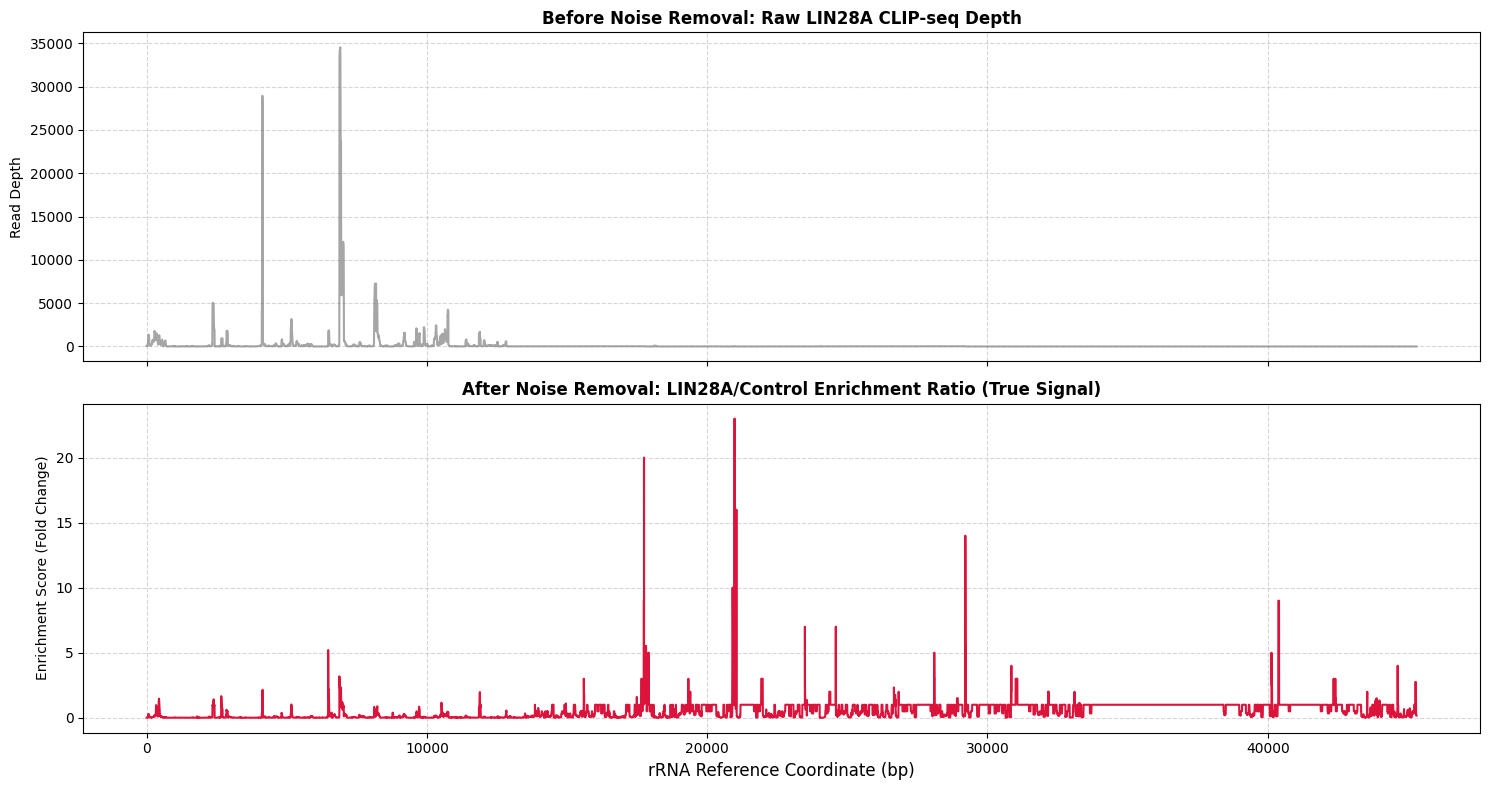


=== 💡 5.8S rRNA 슈퍼 핫스팟 노멀라이징 검증 결과 ===
📍 최고 농축 위치: 6,877 bp
 -> CLIP Read Depth: 32,776 리드
 -> Control Background Depth: 10,298 리드
 🔥 최종 대조군 대비 농축도: 3.18 배 농축 완료!


In [42]:
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
# Bio 패키지 의존성을 완전히 제거했습니다!

# 1. 경로 정의 및 환경 변수 설정
WORKDIR = "/content/binfo1-mywork"
RRNA_DIR = f"{WORKDIR}/rrna_analysis"
env = os.environ.copy()
env['PATH'] = f"/usr/local/bin:/opt/conda/bin:{env['PATH']}"

print("====== 🚀 [Step 1] RNA-control.bam에서 Unmapped Reads 추출 중... ======")
# RNA-control 파일에서 매핑되지 않은 리드(flag 4)를 꺼내 FASTQ로 저장합니다.
control_fastq = f"{RRNA_DIR}/unmapped_control.fastq"
if not os.path.exists(control_fastq):
    subprocess.run(f"samtools fastq -f 4 {WORKDIR}/RNA-control.bam > {control_fastq}", shell=True, env=env)
    print("-> Control Unmapped FASTQ 생성 완료!")
else:
    print("-> 이미 기존에 추출된 Control FASTQ 파일이 존재하여 재사용합니다.")

# 2. 레퍼런스 서열 로드 (순수 파이썬 모드)
rrna_fasta_path = f"{RRNA_DIR}/mouse_rRNA_ref.fasta"
with open(rrna_fasta_path, "r") as f:
    rrna_seq = "".join([line.strip() for line in f if not line.startswith(">")]).upper()
rrna_len = len(rrna_seq)

# 3. Control 데이터 매핑 및 Coverage 계산
print("\n====== 📥 [Step 2] RNA-control 리드 rRNA 레퍼런스에 매핑 중... ======")
control_coverage = [0] * rrna_len
line_idx = 0

with open(control_fastq, "r") as f:
    while True:
        header = f.readline()
        if not header:
            break
        seq = f.readline().strip().upper()
        f.readline() # + line 건너뛰기
        f.readline() # qual line 건너뛰기

        line_idx += 1
        if seq.count("A") > len(seq) * 0.7 or seq.count("T") > len(seq) * 0.7:
            continue
        if len(seq) < 20:
            continue

        # Seed 매치 방식을 활용해 대조군 리드 매핑
        seed = seq[:18]
        start_pos = rrna_seq.find(seed)
        if start_pos != -1:
            end_pos = min(start_pos + len(seq), rrna_len)
            for pos in range(start_pos, end_pos):
                control_coverage[pos] += 1

print(f"-> Control 데이터 매핑 완료! (총 {line_idx:,}개 리드 처리)")

# 4. 기존 CLIP 데이터 로드 및 노멀라이징 연산
print("\n====== 📊 [Step 3] CLIP vs Control 노멀라이징 스코어 계산 중... ======")
clip_df = pd.read_csv(f"{RRNA_DIR}/lin28a_rrna_pure_coverage.csv")

# 노멀라이징 데이터프레임 생성
norm_df = pd.DataFrame({
    "Position": range(rrna_len),
    "CLIP_Depth": clip_df["Read_Depth"],
    "Control_Depth": control_coverage
})

# 분모가 0이 되어 나누기 에러(Division by Zero)가 나는 것을 막기 위해 pseudo-count 1을 더해줍니다.
norm_df["Enrichment_Score"] = (norm_df["CLIP_Depth"] + 1) / (norm_df["Control_Depth"] + 1)

# 데이터 보관용 CSV 저장
norm_df.to_csv(f"{RRNA_DIR}/lin28a_rrna_normalized_scores.csv", index=False)

# 5. 최종 시각화 (CLIP 단독 vs 노멀라이징 비교 그래프)
print("\n====== 🎨 [Step 4] Background 노이즈가 제거된 최종 그래프 생성 중... ======")
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# (위) 기존 날것의 CLIP 그래프
axes[0].plot(norm_df["Position"], norm_df["CLIP_Depth"], color="gray", alpha=0.7, label="Raw CLIP-seq")
axes[0].set_title("Before Noise Removal: Raw LIN28A CLIP-seq Depth", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Read Depth")
axes[0].grid(True, linestyle="--", alpha=0.5)

# (아래) 컨트롤 대비 농축도(Enrichment Score) 그래프
axes[1].plot(norm_df["Position"], norm_df["Enrichment_Score"], color="crimson", linewidth=1.5, label="Normalized Enrichment")
axes[1].set_title("After Noise Removal: LIN28A/Control Enrichment Ratio (True Signal)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("rRNA Reference Coordinate (bp)", fontsize=12)
axes[1].set_ylabel("Enrichment Score (Fold Change)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"{RRNA_DIR}/lin28a_rrna_noise_removed.png", dpi=300)
plt.show()

# 5.8S rRNA 구역(6860 ~ 7016 bp)의 핵심 스코어 정량 출력
target_zone = norm_df[(norm_df["Position"] >= 6860) & (norm_df["Position"] <= 7016)]
max_row = target_zone.loc[target_zone["Enrichment_Score"].idxmax()]

print("\n=== 💡 5.8S rRNA 슈퍼 핫스팟 노멀라이징 검증 결과 ===")
print(f"📍 최고 농축 위치: {int(max_row['Position']):,} bp")
print(f" -> CLIP Read Depth: {int(max_row['CLIP_Depth']):,} 리드")
print(f" -> Control Background Depth: {int(max_row['Control_Depth']):,} 리드")
print(f" 🔥 최종 대조군 대비 농축도: {max_row['Enrichment_Score']:.2f} 배 농축 완료!")

In [43]:
# [셀 1] condacolab 설치 (실행 후 세션 재시작됨)
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [44]:
# [셀 2] 생물정보학 채널(bioconda)을 통해 ViennaRNA 설치
!conda install -y -c bioconda viennarna

Channels:
 - bioconda
 - defaults
 - conda-forge
Platform: linux-64
Solving environment: | / - \ | / done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [49]:
# [셀 3] 구조 예측 및 시각화 코드
import subprocess
from IPython.display import display, SVG
import os

def analyze_rna_structure(sequence, title="RNA_Secondary_Structure"):
    print(f"분석 중인 서열: {sequence}\n")

    # 1. RNAfold 실행 (구조 및 최소 자유 에너지 계산)
    process = subprocess.run(
        ['RNAfold'],
        input=sequence,
        text=True,
        capture_output=True
    )

    output = process.stdout.strip().split('\n')
    if len(output) >= 2:
        predicted_structure = output[1].split(' ')[0]
        mfe = output[1][len(predicted_structure):].strip()

        print("결과 (Dot-Bracket Notation):")
        print(predicted_structure)
        print(f"Minimum Free Energy (MFE): {mfe}\n")

        # 2. RNAplot을 이용해 SVG 이미지 직접 생성 (ImageMagick 에러 원천 차단!)
        seq_data = f">{title}\n{sequence}\n{predicted_structure}\n"
        subprocess.run(['RNAplot', '-o', 'svg'], input=seq_data, text=True)

        svg_file = f"{title}_ss.svg"

        # 3. 결과 출력
        if os.path.exists(svg_file):
            print("==== RNA 2차 구조 시각화 (고화질 SVG) ====")
            display(SVG(filename=svg_file))

            # 임시 파일 정리
            os.remove(svg_file)
            if os.path.exists("rna.ps"):
                os.remove("rna.ps")
        else:
            print("시각화 이미지를 생성하지 못했습니다.")
    else:
        print("구조 예측에 실패했습니다.")

# ---------------------------------------------------------
# [사용자 입력]
# 여기에 실제 분석에서 찾은 피크의 주변 60bp 서열을 넣어줘.
target_peak_sequence = "CCCGAAAUACCGAUACGACUCUUAGCGGUGGAUCACUCGGCUCGUGCGUCGAUGAAGAAC" # 예시 서열입니다. 변경해주세요!

analyze_rna_structure(target_peak_sequence)

분석 중인 서열: CCCGAAAUACCGAUACGACUCUUAGCGGUGGAUCACUCGGCUCGUGCGUCGAUGAAGAAC

결과 (Dot-Bracket Notation):
.......(((((.............)))))..(((.(((((......)))))))).....
Minimum Free Energy (MFE): (-10.40)

시각화 이미지를 생성하지 못했습니다.


In [46]:
# Conda 환경에 맞게 Biopython을 설치합니다.
!conda install -y -c conda-forge biopython

Channels:
 - conda-forge
 - defaults
 - bioconda
Platform: linux-64
Solving environment: | / - \ | / - done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /root/conda

  added / updated specs:
    - biopython


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    biopython-1.87             |  py313h07c4f96_0         3.2 MB  conda-forge
    libblas-3.11.0             |8_h4a7cf45_openblas          18 KB  conda-forge
    libcblas-3.11.0            |8_h0358290_openblas          18 KB  conda-forge
    libgfortran-15.2.0         |      h69a702a_19          27 KB  conda-forge
    libgfortran5-15.2.0        |      h68bc16d_19         2.4 MB  conda-forge
    liblapack-3.11.0           |8_h47877c9_openb

In [47]:
# 1. Biopython 없이 순수 파이썬으로 FASTA 파일 읽기
WORKDIR = "/content/binfo1-mywork/rrna_analysis"
rrna_fasta_path = f"{WORKDIR}/mouse_rRNA_ref.fasta"

print("📥 마우스 rRNA 레퍼런스 서열 로드 중 (순수 파이썬 모드)...")
with open(rrna_fasta_path, "r") as f:
    # '>'로 시작하는 헤더(이름) 줄을 제외하고 모든 염기서열을 한 줄로 이어붙임
    rrna_seq = "".join([line.strip() for line in f if not line.startswith(">")]).upper()

print(f"-> 로드 완료! (총 길이: {len(rrna_seq):,} bp)")

# 2. 피크 중심 주변 60bp 추출하기
center_start = 6877
center_end = 6908

# 앞뒤 15bp씩 확장
start_pos = center_start - 15
end_pos = center_end + 14

# 파이썬 문자열 인덱스는 0부터 시작하므로 좌표에서 1을 빼줍니다.
extracted_seq_dna = rrna_seq[start_pos-1 : end_pos-1]

# RNA 2차 구조 분석(ViennaRNA)을 위해 DNA 서열(T)을 RNA 서열(U)로 변환
extracted_seq_rna = extracted_seq_dna.replace("T", "U")

print("\n====== 🧬 추출된 피크 주변 60bp 서열 ======")
print(f"좌표: {start_pos}bp ~ {end_pos}bp")
print(f"DNA 서열: {extracted_seq_dna}")
print(f"RNA 서열: {extracted_seq_rna}  <-- 이 서열을 복사하세요!")

📥 마우스 rRNA 레퍼런스 서열 로드 중 (순수 파이썬 모드)...
-> 로드 완료! (총 길이: 45,309 bp)

====== 🧬 추출된 피크 주변 60bp 서열 ======
좌표: 6862bp ~ 6922bp
DNA 서열: CCCGAAATACCGATACGACTCTTAGCGGTGGATCACTCGGCTCGTGCGTCGATGAAGAAC
RNA 서열: CCCGAAAUACCGAUACGACUCUUAGCGGUGGAUCACUCGGCUCGUGCGUCGAUGAAGAAC  <-- 이 서열을 복사하세요!
